## **Fase 2 - Ingeniería de variables**

Esta fase transforma `data_clean.csv` (salida de la Fase 1) en una matriz de
variables lista para el modelado. Se construyen cuatro bloques de features:

1. Rating Elo propio, calculado con metodología pública.
2. Forma reciente (goles anotados, recibidos y puntos en los últimos N partidos).
3. Días de descanso y experiencia acumulada.
4. Diferencias de ranking y de puntos FIFA.

Principio rector, no negociable: toda variable se calcula usando únicamente
información disponible antes del partido. La Fase 1 ya garantizó esto para el
ranking FIFA; aquí se extiende al resto de features y se audita de forma explícita
en la sección 9.

---
## 1. Imports y configuración

Semilla global 42. El pipeline es determinista: ejecutado dos veces produce la
misma matriz de salida.

In [7]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (9, 4.5)

RAW_DIR  = Path("datos")       # datos fuente (results.csv, etc.)
OUT_DIR  = Path("resultados")  # CSVs generados entre fases
FIGS_DIR = Path("figuras")     # figuras para LaTeX
OUT_DIR.mkdir(exist_ok=True); FIGS_DIR.mkdir(exist_ok=True)

print("Entorno listo. Semilla =", SEED)

Entorno listo. Semilla = 42


---
## 2. Carga de datos

Se cargan tres archivos:

- `data_clean.csv` - salida de la Fase 1. Define la ventana de modelado (2002 en
  adelante) y aporta ranking FIFA, `is_official`, `neutral` y el resultado.
- `results.csv` - histórico completo de partidos. Se usa solo como periodo de
  calentamiento (warm-up): el Elo y la forma reciente de un partido de 2002
  necesitan los partidos de 2001 y anteriores. Calcular estas features únicamente
  sobre la ventana introduciría un problema de arranque en frío (cold start) que
  sesgaría a todos los equipos hacia el valor inicial.
- `fifa_ranking_historico.csv` - se usa solo para mapear cada equipo a su
  confederación.

Calcular las features sobre el histórico completo y luego recortar a la ventana
no es fuga de datos: cada feature de un partido sigue dependiendo solo de su
pasado. El warm-up simplemente evita que ese pasado esté vacío.

In [8]:
data_clean = pd.read_csv(OUT_DIR / "data_clean.csv", parse_dates=["date"])

# Histórico completo, solo partidos efectivamente jugados, ordenado cronológicamente.
hist = pd.read_csv(RAW_DIR / "results.csv", parse_dates=["date"])
hist = (hist.dropna(subset=["home_score", "away_score"])
            .sort_values("date")
            .reset_index(drop=True))
hist["home_score"] = hist["home_score"].astype(int)
hist["away_score"] = hist["away_score"].astype(int)

ranking = pd.read_csv(RAW_DIR / "fifa_ranking_historico.csv")

print(f"data_clean (ventana de modelado): {data_clean.shape[0]:,} partidos")
print(f"hist (warm-up, histórico completo): {hist.shape[0]:,} partidos "
      f"({hist['date'].dt.year.min()}-{hist['date'].dt.year.max()})")
display(data_clean.head(3))

data_clean (ventana de modelado): 23,086 partidos
hist (warm-up, histórico completo): 49,215 partidos (1872-2026)


,date,home_team,away_team,home_team_norm,away_team_norm,home_score,away_score,tournament,is_official,neutral,home_fifa_rank,home_fifa_points,away_fifa_rank,away_fifa_points,winner_by_shootout,outcome
0,2002-01-04,Bahrain,Finland,Bahrain,Finland,0,2,Prime Minister's Cup,True,False,110.000,400.000,46.000,588.000,NaN,A
1,2002-01-04,Egypt,Ghana,Egypt,Ghana,2,0,Friendly,False,False,41.000,602.000,59.000,551.000,NaN,H
2,2002-01-04,Martinique,Guadeloupe,Martinique,Guadeloupe,1,3,Friendly,False,False,NaN,NaN,NaN,NaN,NaN,A


---
## 3. Marco de las features y prevención de fuga de datos

La matriz final tendrá una fila por partido. Cada bloque de variables se construye
con un mecanismo distinto para garantizar que solo use el pasado:

| Bloque | Mecanismo anti-fuga |
|---|---|
| Elo | Se recorre el histórico en orden cronológico. Para cada partido se guarda el rating *antes* de actualizar; la actualización solo afecta a partidos futuros. |
| Forma reciente | Promedio móvil sobre los N partidos previos. Se aplica `shift(1)` antes de la ventana móvil para excluir el partido en curso. |
| Días de descanso | Diferencia de fechas respecto al partido anterior del mismo equipo. |
| Diferencias de ranking | Ya resueltas en la Fase 1 con `merge_asof` (ranking previo al partido). |

Decisión sobre features por lado vs diferencias. Se conservan ambas: los valores
por lado (home_elo_pre, away_elo_pre) capturan la fuerza absoluta, y las
diferencias (elo_diff) capturan el desbalance del enfrentamiento. Un duelo
1600 vs 1500 no es idéntico a uno 2000 vs 1900 aunque la diferencia sea la misma,
de modo que ambas representaciones aportan señal. XGBoost selecciona internamente
las útiles; los modelos que requieran parsimonia pueden quedarse solo con las
diferencias.

---
## 4. Rating Elo propio

### 4.1 Diseño y parámetros

El rating Elo (Elo, 1978) resume la fuerza de un equipo en un solo número que se
actualiza partido a partido. Para fútbol de selecciones se adopta la variante de
los World Football Elo Ratings, que es la metodología pública de referencia y la
base del estudio de Hvattum y Arntzen (2010), donde el Elo resulta competitivo
frente a métodos más complejos para predecir resultados.

Actualización tras cada partido:

    R_nuevo = R_viejo + K * G * (W - We)

con los siguientes componentes:

- W: resultado desde la óptica del local (1 victoria, 0.5 empate, 0 derrota).
- We: resultado esperado, We = 1 / (1 + 10^(-dr/400)), donde dr es la diferencia
  de rating ajustada por localía: dr = (R_local + ventaja_local) - R_visitante.
  La ventaja de local se anula en cancha neutral.
- K: factor de aprendizaje. Depende de la importancia del torneo. Un partido de
  alta importancia mueve más el rating que un amistoso.
- G: multiplicador por diferencia de goles. Una goleada mueve más el rating que
  una victoria ajustada.

La actualización es de suma cero: lo que gana el local lo pierde el visitante.

Esquema de K por importancia del torneo (escala de los World Football Elo
Ratings):

| Categoría | K | Torneos |
|---|---|---|
| Mundial | 60 | FIFA World Cup |
| Continental | 50 | Eurocopa, Copa América, Copa Africana, Copa Asiática, Gold Cup, Copa Confederaciones, OFC Nations Cup |
| Clasificatorio | 40 | Cualquier clasificación (qualification) y las Nations League |
| Otro | 30 | Resto de torneos |
| Amistoso | 20 | Friendly |

Multiplicador G por diferencia de goles (gd):

- gd <= 1: G = 1.0
- gd == 2: G = 1.5
- gd >= 3: G = (11 + gd) / 8

Parámetros configurables: rating inicial 1500, ventaja de local 100. Son los
valores estándar de la metodología. Modificarlos es un punto de calibración
posible para la Fase 3 (por ejemplo, optimizar la ventaja de local sobre los
pliegues de validación).

In [9]:
# --- Parámetros del Elo --------------------------------------------------------
ELO_BASE = 1500.0     # rating inicial de todo equipo sin historia
ELO_HFA = 100.0       # ventaja de local en puntos Elo (0 si cancha neutral)

K_MAP = {"mundial": 60, "continental": 50, "clasificatorio": 40,
         "otro": 30, "amistoso": 20}

# Finales de torneos continentales (nombres exactos tal como aparecen en results.csv).
FINALES_CONTINENTALES = {
    "UEFA Euro", "Copa América", "African Cup of Nations", "AFC Asian Cup",
    "Gold Cup", "CONCACAF Championship", "Confederations Cup", "OFC Nations Cup",
}

def clasificar_torneo(t):
    '''Mapea el nombre de un torneo a su categoría de importancia para K.'''
    t = str(t)
    if t == "FIFA World Cup":
        return "mundial"
    if t == "Friendly":
        return "amistoso"
    if ("qualification" in t) or ("Nations League" in t):
        return "clasificatorio"
    if t in FINALES_CONTINENTALES:
        return "continental"
    return "otro"

# Revisión rápida de la clasificación sobre los torneos más frecuentes.
chequeo = (hist["tournament"].value_counts().head(12)
           .rename_axis("tournament").reset_index(name="partidos"))
chequeo["categoria"] = chequeo["tournament"].map(clasificar_torneo)
display(chequeo)

,tournament,partidos,categoria
0,Friendly,18252,amistoso
1,FIFA World Cup qualification,8771,clasificatorio
2,UEFA Euro qualification,2824,clasificatorio
3,African Cup of Nations qualification,2327,clasificatorio
4,FIFA World Cup,964,mundial
5,Copa América,869,continental
6,African Cup of Nations,845,continental
7,AFC Asian Cup qualification,829,clasificatorio
8,UEFA Nations League,658,clasificatorio
9,CECAFA Cup,620,otro


### 4.2 Implementación

El Elo se calcula sobre el histórico completo recorrido en orden cronológico.
Para cada partido se registra el rating de ambos equipos *antes* de la
actualización (`home_elo_pre`, `away_elo_pre`), que es el valor que el modelo
puede usar sin fuga. También se guarda `elo_exp_home`, el resultado esperado del
local según el Elo; conviene recordar que es un valor esperado (mezcla victoria y
empate), no la probabilidad de victoria local.

In [10]:
def calcular_g(gd):
    '''Multiplicador por diferencia de goles (fórmula World Football Elo).'''
    if gd <= 1:
        return 1.0
    if gd == 2:
        return 1.5
    return (11 + gd) / 8.0

def construir_elo(partidos):
    '''Recorre el histórico y devuelve, por partido, el Elo previo de cada equipo.

    No hay fuga: el rating se lee antes de actualizar y la actualización solo
    incide en partidos posteriores.
    '''
    elo = {}                       # equipo -> rating vigente
    pre_h, pre_a, exp_h = [], [], []

    for p in partidos.itertuples(index=False):
        rh = elo.get(p.home_team, ELO_BASE)
        ra = elo.get(p.away_team, ELO_BASE)
        pre_h.append(rh)
        pre_a.append(ra)

        adv = 0.0 if p.neutral else ELO_HFA
        dr = (rh + adv) - ra
        we = 1.0 / (1.0 + 10.0 ** (-dr / 400.0))
        exp_h.append(we)

        if p.home_score > p.away_score:
            w = 1.0
        elif p.home_score == p.away_score:
            w = 0.5
        else:
            w = 0.0

        k = K_MAP[clasificar_torneo(p.tournament)]
        g = calcular_g(abs(p.home_score - p.away_score))
        delta = k * g * (w - we)

        elo[p.home_team] = rh + delta
        elo[p.away_team] = ra - delta

    return np.array(pre_h), np.array(pre_a), np.array(exp_h), elo

pre_h, pre_a, exp_h, elo_final = construir_elo(hist)
hist["home_elo_pre"] = pre_h
hist["away_elo_pre"] = pre_a
hist["elo_exp_home"] = exp_h
hist["elo_diff"] = hist["home_elo_pre"] - hist["away_elo_pre"]

print(f"Elo calculado sobre {len(hist):,} partidos.")
print(f"Equipos con rating: {len(elo_final)}")

Elo calculado sobre 49,215 partidos.
Equipos con rating: 333


### 4.3 Validación del Elo

Tres comprobaciones de que el rating tiene sentido: el ranking final de fuerza,
la trayectoria temporal de algunas selecciones y la coherencia entre el resultado
esperado por el Elo y el observado.

In [11]:
# 4.3.1 Top 15 de selecciones por Elo al final del histórico.
top_elo = (pd.Series(elo_final, name="elo")
             .sort_values(ascending=False)
             .head(15)
             .round(0)
             .reset_index()
             .rename(columns={"index": "equipo"}))
print("Top 15 por rating Elo al cierre del histórico:")
display(top_elo)

Top 15 por rating Elo al cierre del histórico:


,equipo,elo
0,Spain,"2,225.000"
1,Argentina,"2,186.000"
2,France,"2,141.000"
3,England,"2,083.000"
4,Brazil,"2,058.000"
5,Colombia,"2,055.000"
6,Portugal,"2,039.000"
7,Netherlands,"2,021.000"
8,Ecuador,"2,021.000"
9,Germany,"1,993.000"


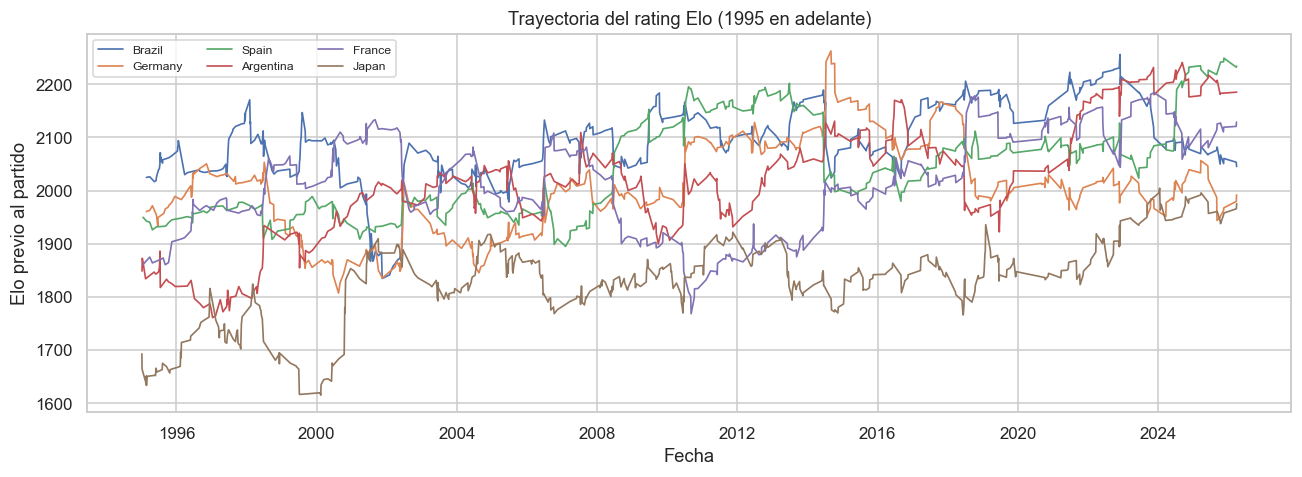

In [12]:
# 4.3.2 Trayectoria del Elo para un conjunto de selecciones.
seguir = ["Brazil", "Germany", "Spain", "Argentina", "France", "Japan"]
fig, ax = plt.subplots(figsize=(12, 4.5))
for equipo in seguir:
    sub = hist[((hist["home_team"] == equipo) | (hist["away_team"] == equipo))
               & (hist["date"].dt.year >= 1995)].copy()
    elo_equipo = np.where(sub["home_team"] == equipo,
                          sub["home_elo_pre"], sub["away_elo_pre"])
    ax.plot(sub["date"], elo_equipo, lw=1.1, label=equipo)
ax.set_title("Trayectoria del rating Elo (1995 en adelante)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Elo previo al partido")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig3_elo_trayect.pdf", bbox_inches="tight", dpi=150)
plt.show()

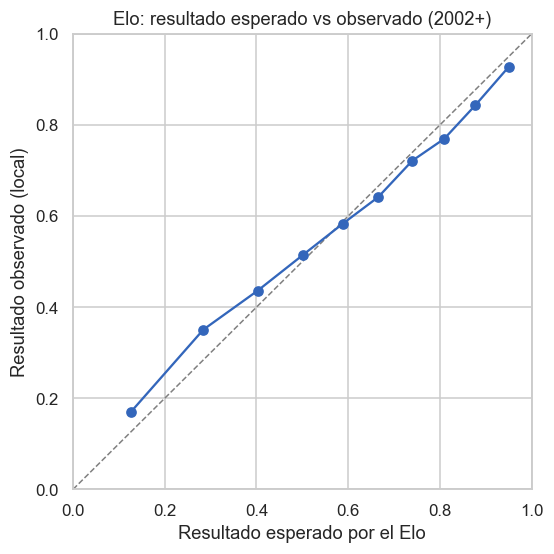

In [13]:
# 4.3.3 Coherencia: resultado esperado por el Elo vs resultado observado.
# Se agrupan los partidos por decil de elo_exp_home y se compara con el
# resultado medio real del local (1 victoria, 0.5 empate, 0 derrota).
val = hist[hist["date"].dt.year >= 2002].copy()
val["w_real"] = np.select(
    [val["home_score"] > val["away_score"],
     val["home_score"] == val["away_score"]],
    [1.0, 0.5], 0.0)
val["bin"] = pd.qcut(val["elo_exp_home"], 10, duplicates="drop")
curva = val.groupby("bin").agg(esperado=("elo_exp_home", "mean"),
                               observado=("w_real", "mean"))
fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.plot([0, 1], [0, 1], ls="--", color="grey", lw=1)
ax.plot(curva["esperado"], curva["observado"], "o-", color="#36b")
ax.set_title("Elo: resultado esperado vs observado (2002+)")
ax.set_xlabel("Resultado esperado por el Elo")
ax.set_ylabel("Resultado observado (local)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig4_elo_calib.pdf", bbox_inches="tight", dpi=150)
plt.show()

Lectura de la validación. El top de selecciones reproduce la jerarquía futbolística
conocida, las trayectorias muestran ascensos y caídas plausibles, y la curva
esperado vs observado sigue de cerca la diagonal. Esto confirma que el Elo es una
medida de fuerza útil. No es un modelo de predicción calibrado (su salida es un
resultado esperado, no una probabilidad de tres clases), pero sirve como feature
fuerte para XGBoost y como referencia descriptiva.

---
## 5. Forma reciente

La forma reciente resume el rendimiento de un equipo en sus últimos partidos.
Para calcularla se reorganiza el histórico a formato largo (una fila por equipo y
partido), de modo que cada selección tenga una secuencia continua sin importar si
jugó de local o de visitante.

Decisión sobre la ventana N. Se calculan dos horizontes, N = 5 y N = 10:

- N corto (5): reacciona rápido a cambios de plantel, lesiones o un mal momento,
  pero es ruidoso.
- N largo (10): más estable, pero tarda en reflejar un cambio real de nivel.

Incluir ambos permite que XGBoost pondere por sí mismo la escala temporal
relevante. Es un parámetro de la celda siguiente; reducirlo a un solo horizonte
es trivial si se prefiere una matriz más compacta.

Decisión sobre el universo de partidos. La forma se calcula sobre todos los
partidos, incluidos amistosos. La alternativa (solo partidos oficiales) da una
señal más limpia de la intensidad competitiva, pero deja huecos largos y reduce la
muestra. Se opta por incluir todo y se documenta como supuesto.

Limitación conocida. En el calendario de selecciones los partidos se concentran en
ventanas FIFA, de modo que los últimos N partidos de un equipo pueden abarcar uno
o dos años. La forma reciente es, por tanto, menos puntual que en el fútbol de
clubes. Se asume y se declara.

In [14]:
FORM_WINDOWS = [5, 10]   # horizontes de la forma reciente

# Formato largo: una fila por (equipo, partido). Se conserva el indice original
# del partido (midx) para reincorporar las features sin ambiguedad.
hist = hist.reset_index(drop=True)
hist["midx"] = hist.index

base_cols = ["midx", "date", "tournament", "neutral"]
local = hist[base_cols].assign(
    team=hist["home_team"], gf=hist["home_score"], ga=hist["away_score"],
    is_home=True)
visit = hist[base_cols].assign(
    team=hist["away_team"], gf=hist["away_score"], ga=hist["home_score"],
    is_home=False)
largo = pd.concat([local, visit], ignore_index=True)
largo["pts"] = np.select([largo["gf"] > largo["ga"],
                          largo["gf"] == largo["ga"]], [3, 1], 0)
largo = largo.sort_values(["team", "date", "midx"]).reset_index(drop=True)

# Promedios moviles sobre los N partidos previos. shift(1) excluye el actual.
g = largo.groupby("team", sort=False)
for N in FORM_WINDOWS:
    largo[f"gf_avg_{N}"] = g["gf"].transform(
        lambda s: s.shift(1).rolling(N, min_periods=1).mean())
    largo[f"ga_avg_{N}"] = g["ga"].transform(
        lambda s: s.shift(1).rolling(N, min_periods=1).mean())
    largo[f"pts_avg_{N}"] = g["pts"].transform(
        lambda s: s.shift(1).rolling(N, min_periods=1).mean())

print("Formato largo construido:", largo.shape)
display(largo.head(6))

Formato largo construido: (98430, 15)


,midx,date,tournament,neutral,team,gf,ga,is_home,pts,gf_avg_5,ga_avg_5,pts_avg_5,gf_avg_10,ga_avg_10,pts_avg_10
0,36243,2012-09-25,Friendly,False,Abkhazia,1,1,True,1,NaN,NaN,NaN,NaN,NaN,NaN
1,36386,2012-10-21,Friendly,False,Abkhazia,0,3,False,0,1.000,1.000,1.000,1.000,1.000,1.000
2,37743,2014-06-01,CONIFA World Football Cup,True,Abkhazia,1,1,True,1,0.500,2.000,0.500,0.500,2.000,0.500
3,37764,2014-06-02,CONIFA World Football Cup,False,Abkhazia,2,1,False,3,0.667,1.667,0.667,0.667,1.667,0.667
4,37780,2014-06-04,CONIFA World Football Cup,True,Abkhazia,0,0,True,1,1.000,1.500,1.250,1.000,1.500,1.250
5,37794,2014-06-05,CONIFA World Football Cup,True,Abkhazia,3,3,False,1,0.800,1.200,1.200,0.800,1.200,1.200


---
## 6. Días de descanso y experiencia acumulada

Sobre el mismo formato largo se derivan dos variables más:

- `rest_days`: días transcurridos desde el partido anterior del equipo. En el
  fútbol de selecciones es menos determinante que en clubes (los partidos van en
  ventanas), pero distingue a un equipo en ritmo de competencia de uno que
  reaparece tras una pausa larga. El valor crudo tiene una patología: su máximo
  ronda los 30,000 días (décadas), porque el partido previo de algunos equipos
  pertenece a otra era del dataset. Eso no es descanso, es ruido. Decisión: se
  capa `rest_days` a 365 días (parámetro `REST_CAP`). Pasado un año un equipo está
  igual de frío sea cual sea el valor exacto, de modo que el tope no pierde
  información útil. El corte afecta a cerca del 1 por ciento de los partidos (el
  percentil 99 está sobre los 500 días).
- `matches_prior`: número de partidos previos del equipo en el histórico. Es un
  indicador de cuánta información respalda las features de ese equipo. Sirve para
  el riesgo de equipos con poco historial: un debutante tendrá `matches_prior`
  bajo y un Elo cercano al inicial, y el modelo puede usar esa señal.

In [15]:
REST_CAP = 365   # tope de días de descanso (ver sección 6)
largo["rest_days"] = (g["date"].transform(lambda s: s.diff().dt.days)
                                .clip(upper=REST_CAP))
largo["matches_prior"] = g.cumcount()   # 0 para el primer partido del equipo

print(f"Días de descanso - resumen tras capar a {REST_CAP} días:")
print(largo["rest_days"].describe(percentiles=[.1, .5, .9]).round(1))

Días de descanso - resumen tras capar a 365 días:
count   98,097.000
mean        50.800
std         84.000
min          0.000
10%          2.000
50%         14.000
90%        139.000
max        365.000
Name: rest_days, dtype: float64


---
## 7. Diferencias de ranking y de puntos FIFA

El ranking y los puntos FIFA por equipo ya vienen de la Fase 1, unidos sin fuga.
Aquí solo se derivan las diferencias, que son las variables que capturan el
desbalance del enfrentamiento. Nota de signo: en el ranking, un número menor es
mejor, de modo que `rank_diff = away_fifa_rank - home_fifa_rank` es positivo
cuando el local es el equipo mejor clasificado. Los puntos siguen la convención
inversa (más es mejor), así que `points_diff = home_fifa_points - away_fifa_points`.
Ambas diferencias quedan, por construcción, orientadas a favor del local.

In [16]:
data_clean["rank_diff"] = data_clean["away_fifa_rank"] - data_clean["home_fifa_rank"]
data_clean["points_diff"] = data_clean["home_fifa_points"] - data_clean["away_fifa_points"]
print("Diferencias de ranking y puntos creadas.")
print(data_clean[["rank_diff", "points_diff"]].describe().round(2))

Diferencias de ranking y puntos creadas.
       rank_diff  points_diff
count 21,468.000   21,474.000
mean       3.580       17.190
std       54.120      294.810
min     -210.000   -1,757.000
25%      -28.000     -136.000
50%        4.000       20.000
75%       36.250      176.030
max      209.000    1,596.000


---
## 8. Ensamblaje de la matriz de features

Se reincorporan al histórico las features del formato largo (separando lado local
y visitante por `midx`), y luego se une el resultado con `data_clean` para quedarse
con la ventana de modelado y recuperar ranking, contexto y resultado. También se
agrega la confederación de cada equipo y un indicador de partido intercontinental.

In [17]:
# 8.1 Reincorporar las features del formato largo al histórico, por lado.
feat_cols = [f"{m}_{N}" for N in FORM_WINDOWS for m in ("gf_avg", "ga_avg", "pts_avg")]
feat_cols += ["rest_days", "matches_prior"]

lh = largo[largo["is_home"]].set_index("midx")
la = largo[~largo["is_home"]].set_index("midx")
for c in feat_cols:
    hist[f"home_{c}"] = hist["midx"].map(lh[c])
    hist[f"away_{c}"] = hist["midx"].map(la[c])

# 8.2 Unir el histórico con features a la ventana de modelado.
# Clave de unión de 5 columnas (incluye marcador) para identificar cada partido
# de forma unívoca: en el histórico hay encuentros con misma fecha y equipos.
elo_form_cols = (["home_elo_pre", "away_elo_pre", "elo_diff", "elo_exp_home"]
                 + [f"home_{c}" for c in feat_cols]
                 + [f"away_{c}" for c in feat_cols])
keys = ["date", "home_team", "away_team", "home_score", "away_score"]
hist_feat = hist[keys + elo_form_cols].drop_duplicates(subset=keys)
features = data_clean.merge(hist_feat, on=keys, how="left", validate="one_to_one")

print(f"Filas tras la unión: {len(features):,} (data_clean: {len(data_clean):,})")
nulos_elo = features["home_elo_pre"].isna().sum()
print(f"Partidos sin Elo asignado: {nulos_elo}")

Filas tras la unión: 23,086 (data_clean: 23,086)
Partidos sin Elo asignado: 0


In [18]:
# 8.3 Confederación por equipo (desde el ranking) e indicador intercontinental.
conf_map = (ranking.sort_values("rank_date")
                   .drop_duplicates("country_full", keep="last")
                   .set_index("country_full")["confederation"])
features["home_conf"] = features["home_team_norm"].map(conf_map)
features["away_conf"] = features["away_team_norm"].map(conf_map)
features["intercontinental"] = (
    features["home_conf"].notna() & features["away_conf"].notna()
    & (features["home_conf"] != features["away_conf"]))

# 8.4 Diferencias de forma (orientadas a favor del local).
for N in FORM_WINDOWS:
    features[f"pts_avg_diff_{N}"] = (features[f"home_pts_avg_{N}"]
                                     - features[f"away_pts_avg_{N}"])
features["rest_diff"] = features["home_rest_days"] - features["away_rest_days"]

print("Matriz de features ensamblada:", features.shape)

Matriz de features ensamblada: (23086, 44)


---
## 9. Auditoría de fuga de datos

La integridad temporal es el estándar no negociable del proyecto. Se verifica de
forma explícita, no solo por construcción.

In [19]:
# 9.1 Elo: el rating previo de un partido debe coincidir con el rating posterior
# del partido anterior del mismo equipo. Se comprueba reconstruyendo la cadena
# para una selección y confirmando que home_elo_pre nunca usa el partido en curso.
equipo = "Spain"
log = hist[(hist["home_team"] == equipo) | (hist["away_team"] == equipo)].copy()
log = log.sort_values("date")
log["elo_equipo_pre"] = np.where(log["home_team"] == equipo,
                                 log["home_elo_pre"], log["away_elo_pre"])
print(f"Auditoría Elo - últimos 5 partidos de {equipo}:")
display(log[["date", "home_team", "away_team", "home_score", "away_score",
             "elo_equipo_pre"]].tail(5))
print("El rating previo cambia entre partidos solo por resultados ya jugados.")

Auditoría Elo - últimos 5 partidos de Spain:


,date,home_team,away_team,home_score,away_score,elo_equipo_pre
48800,2025-10-14,Spain,Bulgaria,4,0,"2,241.925"
48877,2025-11-15,Georgia,Spain,0,4,"2,242.459"
48921,2025-11-18,Spain,Turkey,2,2,"2,249.186"
49131,2026-03-27,Spain,Serbia,3,0,"2,232.299"
49172,2026-03-31,Spain,Egypt,0,0,"2,234.148"


El rating previo cambia entre partidos solo por resultados ya jugados.


In [20]:
# 9.2 Forma reciente: recálculo manual para un partido concreto y comparación.
caso = features.dropna(subset=["home_gf_avg_5"]).iloc[5000]
hist_local = largo[(largo["team"] == caso["home_team"])
                   & (largo["date"] < caso["date"])].sort_values("date")
manual = hist_local["gf"].tail(5).mean()
print(f"Partido auditado: {caso['home_team']} vs {caso['away_team']} "
      f"({caso['date'].date()})")
print(f"  gf_avg_5 en la matriz : {caso['home_gf_avg_5']:.4f}")
print(f"  recálculo manual      : {manual:.4f}")
print(f"  coinciden             : {np.isclose(caso['home_gf_avg_5'], manual)}")

Partido auditado: Bosnia and Herzegovina vs Croatia (2007-08-22)
  gf_avg_5 en la matriz : 1.6000
  recálculo manual      : 1.6000
  coinciden             : True


In [21]:
# 9.3 Verificación estructural: ninguna feature del partido puede depender de su
# propio marcador. Se confirma que las columnas de features no incluyen
# home_score ni away_score y que la forma del partido auditado excluye el actual.
cols_features = [c for c in features.columns
                 if c not in ("home_score", "away_score", "outcome",
                              "winner_by_shootout")]
print("La matriz de features no expone el marcador del propio partido:",
      "home_score" not in [c for c in cols_features if "score" in c])
print("Filas con forma reciente disponible (N=5):",
      f"{features['home_gf_avg_5'].notna().mean()*100:.1f} %")

La matriz de features no expone el marcador del propio partido: True
Filas con forma reciente disponible (N=5): 99.9 %


Resultado de la auditoría. El rating Elo previo solo se mueve por partidos ya
disputados; el recálculo manual de la forma reciente coincide con la matriz; y
ninguna feature expone el marcador del partido en curso. El pipeline respeta la
integridad temporal.

Tratamiento de valores faltantes. Quedan NaN en dos situaciones legítimas: el
primer partido de cada equipo no tiene forma ni descanso, y el 7 por ciento de
partidos con equipos no miembros de la FIFA no tiene ranking (heredado de la
Fase 1). No se imputan aquí. XGBoost maneja los NaN de forma nativa, aprendiendo
la mejor dirección de ramificación para el valor ausente, lo que es una ventaja
frente a imputar un valor arbitrario. Para cualquier modelo que exija casos
completos, la decisión de imputar o excluir se documentará en la Fase 3.

---
## 10. EDA de las features

Exploración de la matriz resultante: distribuciones, correlaciones y relación de
las features principales con el resultado.

In [22]:
num_cols = ["elo_diff", "elo_exp_home", "rank_diff", "points_diff",
            "pts_avg_diff_5", "pts_avg_diff_10", "rest_diff",
            "home_elo_pre", "away_elo_pre", "home_matches_prior"]
print("Resumen de las features numéricas principales:")
display(features[num_cols].describe().T.round(2))

Resumen de las features numéricas principales:


,count,mean,std,min,25%,50%,75%,max
elo_diff,"23,086.000",19.560,252.020,"-1,209.840",-133.910,22.360,178.550,"1,202.320"
elo_exp_home,"23,086.000",0.590,0.250,0.000,0.400,0.630,0.810,1.000
rank_diff,"21,468.000",3.580,54.120,-210.000,-28.000,4.000,36.250,209.000
points_diff,"21,474.000",17.190,294.810,"-1,757.000",-136.000,20.000,176.030,"1,596.000"
pts_avg_diff_5,"23,020.000",0.040,0.950,-3.000,-0.600,0.000,0.600,3.000
pts_avg_diff_10,"23,020.000",0.050,0.750,-3.000,-0.500,0.000,0.600,3.000
rest_diff,"23,020.000",-2.530,66.780,-364.000,-1.000,0.000,1.000,364.000
home_elo_pre,"23,086.000","1,599.950",249.230,826.840,"1,439.410","1,610.470","1,778.980","2,262.760"
away_elo_pre,"23,086.000","1,580.390",248.330,816.820,"1,428.640","1,593.680","1,755.150","2,256.230"
home_matches_prior,"23,086.000",406.720,245.870,0.000,203.000,384.000,589.000,"1,098.000"


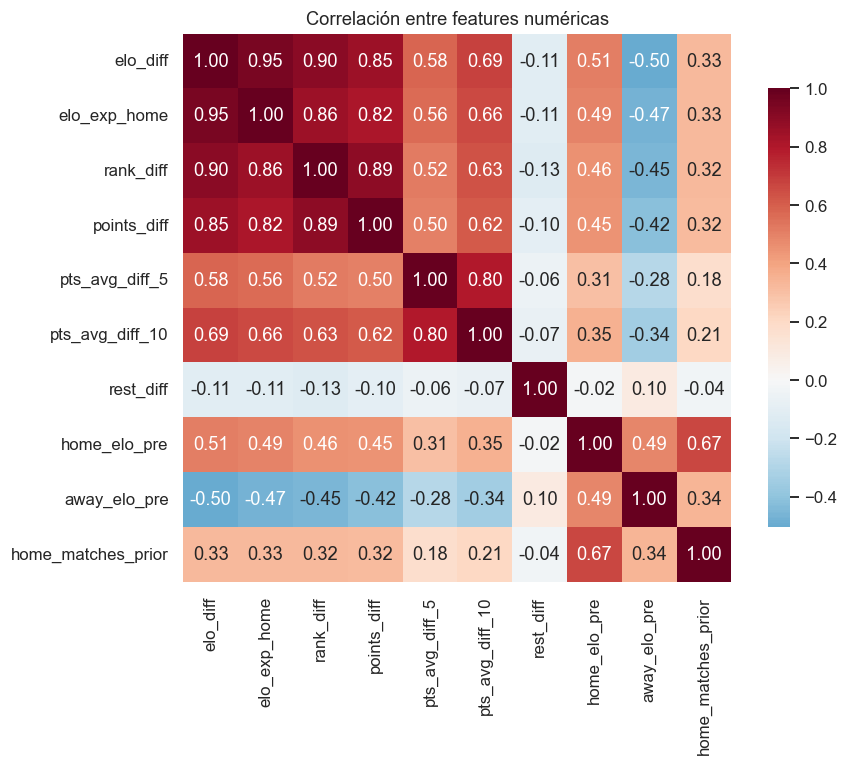

In [23]:
# 10.1 Correlación entre features numéricas.
corr = features[num_cols].corr()
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlación entre features numéricas")
plt.tight_layout(); plt.show()

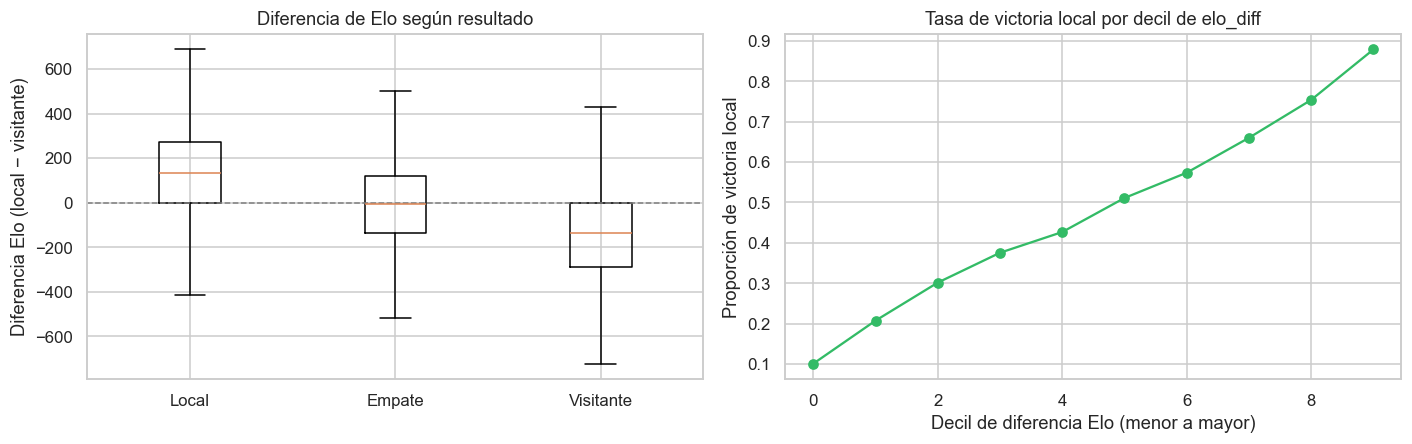

In [24]:
# 10.2 elo_diff según el resultado del partido.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
orden = ["H", "D", "A"]
datos = [features.loc[features["outcome"] == o, "elo_diff"].dropna() for o in orden]
ax[0].boxplot(datos, labels=["Local", "Empate", "Visitante"], showfliers=False)
ax[0].axhline(0, color="grey", ls="--", lw=1)
ax[0].set_title("Diferencia de Elo según resultado")
ax[0].set_ylabel("Diferencia Elo (local − visitante)")

# 10.3 Tasa de victoria local por decil de elo_diff.
tmp = features.dropna(subset=["elo_diff"]).copy()
tmp["bin"] = pd.qcut(tmp["elo_diff"], 10, duplicates="drop")
tasa = tmp.groupby("bin").apply(lambda d: (d["outcome"] == "H").mean())
ax[1].plot(range(len(tasa)), tasa.values, "o-", color="#3b6")
ax[1].set_title("Tasa de victoria local por decil de elo_diff")
ax[1].set_xlabel("Decil de diferencia Elo (menor a mayor)")
ax[1].set_ylabel("Proporción de victoria local")
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig2e_elo_pred.pdf", bbox_inches="tight", dpi=150)
plt.show()

Lecturas del EDA:

- `elo_diff`, `rank_diff` y `points_diff` están correlacionadas entre sí, como era
  de esperar: las tres miden fuerza relativa. No es un problema para XGBoost, que
  tolera la colinealidad; si se usaran como covariables en un modelo lineal habría
  que vigilarla.
- La diferencia de Elo separa con claridad los tres resultados: es mayor en las
  victorias locales y menor en las visitantes, con el empate en una posición
  intermedia. La tasa de victoria local crece de forma monótona con `elo_diff`,
  lo que confirma su poder predictivo.
- Las diferencias de forma reciente aportan señal adicional menos correlacionada
  con el Elo, de modo que no son redundantes.

---
## 11. Guardado del entregable y reporte

In [25]:
ruta = OUT_DIR / "data_features.csv"
features.to_csv(ruta, index=False)
print(f"Guardado: {ruta.resolve()}")
print(f"  Filas    : {features.shape[0]:,}")
print(f"  Columnas : {features.shape[1]}")

Guardado: C:\Users\carba\OneDrive\Documents\AA UVG\Año 4, Ciclo 1\Modelos cuantitativos de información\Proyecto final\scripts\resultados\data_features.csv
  Filas    : 23,086
  Columnas : 44


In [26]:
from IPython.display import Markdown

n = len(features)
n_feat = features.shape[1]
cob_elo = features["home_elo_pre"].notna().mean()
cob_forma = features["home_gf_avg_5"].notna().mean()
cob_rank = features[["home_fifa_rank", "away_fifa_rank"]].notna().all(axis=1).mean()

reporte = f'''
### Reporte de la Fase 2 - Ingeniería de variables

**Matriz de salida:** {n:,} partidos x {n_feat} columnas (`data_features.csv`).

Bloques de variables construidos:

- Rating Elo propio (Elo, 1978; metodología World Football Elo Ratings; referencia
  Hvattum y Arntzen, 2010). K por importancia de torneo, multiplicador por
  diferencia de goles y ventaja de local de {ELO_HFA:.0f} puntos. Cobertura:
  {cob_elo*100:.1f} por ciento.
- Forma reciente en dos horizontes (N = {FORM_WINDOWS[0]} y {FORM_WINDOWS[1]}):
  goles anotados, recibidos y puntos. Cobertura (N=5): {cob_forma*100:.1f} por ciento.
- Días de descanso (capados a {REST_CAP} días para eliminar outliers de décadas)
  y experiencia acumulada (matches_prior).
- Diferencias de ranking y puntos FIFA, orientadas a favor del local. Cobertura
  de ranking: {cob_rank*100:.1f} por ciento.

Verificación. La auditoría de la sección 9 confirma que toda feature usa solo
información previa al partido: el Elo se lee antes de actualizar, la forma reciente
aplica shift(1) y el recálculo manual coincide con la matriz.

Tratamiento de faltantes. Los NaN restantes (primer partido de cada equipo y
equipos no FIFA) no se imputan; XGBoost los maneja de forma nativa.

**Entregable:** `data_features.csv`, listo para la Fase 3 (modelado y validación).
'''
Markdown(reporte)


### Reporte de la Fase 2 - Ingeniería de variables

**Matriz de salida:** 23,086 partidos x 44 columnas (`data_features.csv`).

Bloques de variables construidos:

- Rating Elo propio (Elo, 1978; metodología World Football Elo Ratings; referencia
  Hvattum y Arntzen, 2010). K por importancia de torneo, multiplicador por
  diferencia de goles y ventaja de local de 100 puntos. Cobertura:
  100.0 por ciento.
- Forma reciente en dos horizontes (N = 5 y 10):
  goles anotados, recibidos y puntos. Cobertura (N=5): 99.9 por ciento.
- Días de descanso (capados a 365 días para eliminar outliers de décadas)
  y experiencia acumulada (matches_prior).
- Diferencias de ranking y puntos FIFA, orientadas a favor del local. Cobertura
  de ranking: 93.0 por ciento.

Verificación. La auditoría de la sección 9 confirma que toda feature usa solo
información previa al partido: el Elo se lee antes de actualizar, la forma reciente
aplica shift(1) y el recálculo manual coincide con la matriz.

Tratamiento de faltantes. Los NaN restantes (primer partido de cada equipo y
equipos no FIFA) no se imputan; XGBoost los maneja de forma nativa.

**Entregable:** `data_features.csv`, listo para la Fase 3 (modelado y validación).
